# Skin Disease Classification — HAM10000 (Benign vs Malignant)

**Goal:** Classify dermoscopic skin-lesion images as **Benign vs Malignant** using transfer learning (EfficientNetB0 vs ResNet50), with deep EDA on metadata, multivariate analysis, and comparative evaluation.

**Dataset:** HAM10000 ("Human Against Machine with 10000 training images") — Kaggle.

**Pipeline:**
1. Setup & Imports
2. Download Dataset
3. Metadata EDA — class, age, sex, localisation
4. Multivariate Analysis — age × sex × dx_type × class
5. Image-level EDA — colour stats, dimensions, sample previews
6. Binary Label Mapping (benign / malignant)
7. Balanced Subset Construction (~1500 images)
8. Augmentation Pipeline
9. EfficientNetB0 Training
10. ResNet50 Training
11. Comparative Evaluation
12. Conclusion

## 1. Setup & Imports

In [ ]:
!pip install -q kagglehub seaborn plotly tensorflow scikit-learn opencv-python-headless

In [ ]:
import os, random, shutil, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image
import cv2

from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                              auc, accuracy_score)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set1')
plt.rcParams['figure.figsize'] = (10, 5)
print('TF:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download Dataset

In [ ]:
import kagglehub
DATA_PATH = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')
print('Path:', DATA_PATH)
for r, d, f in os.walk(DATA_PATH):
    print(r, '— files:', len(f))
    if r == DATA_PATH: break

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path: /kaggle/input/skin-cancer-mnist-ham10000
/kaggle/input/skin-cancer-mnist-ham10000 — files: 5


In [ ]:
# Locate metadata and image folders
META_CSV = None
IMG_DIRS = []
for r, _, files in os.walk(DATA_PATH):
    for f in files:
        if f.endswith('.csv') and 'metadata' in f.lower():
            META_CSV = os.path.join(r, f)
        if f.endswith('.jpg'):
            if r not in IMG_DIRS:
                IMG_DIRS.append(r)
print('Metadata CSV :', META_CSV)
print('Image dirs   :', IMG_DIRS)

df = pd.read_csv(META_CSV)
print(df.shape)
df.head()

Metadata CSV : /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image dirs   : ['/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2', '/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2']
(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
# Build a lookup of image_id -> path
img_lookup = {}
for d in IMG_DIRS:
    for f in os.listdir(d):
        if f.endswith('.jpg'):
            img_lookup[f.replace('.jpg','')] = os.path.join(d, f)
df['path'] = df['image_id'].map(img_lookup)
df = df.dropna(subset=['path']).reset_index(drop=True)
print('Rows with image found:', len(df))
df.head()

Rows with image found: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


## 3. Metadata EDA

In [ ]:
print(df.info())
print('\nMissing values:\n', df.isnull().sum())
df['age'] = df['age'].fillna(df['age'].median())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   path          10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB
None

Missing values:
 lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
dtype: int64


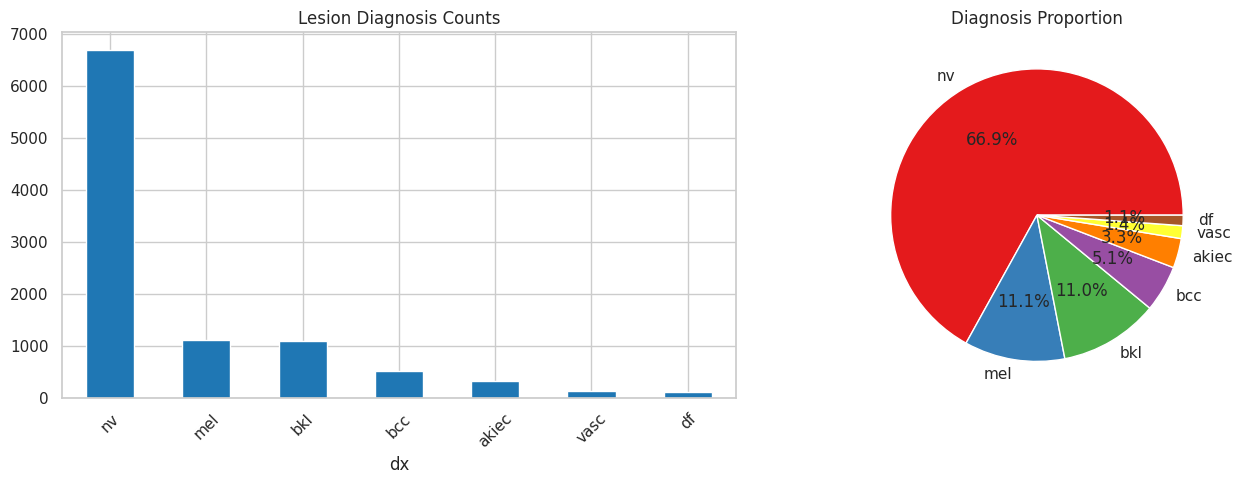

In [ ]:
# 3.1 Diagnosis counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['dx'].value_counts().plot(kind='bar', ax=axes[0], colormap='tab10')
axes[0].set_title('Lesion Diagnosis Counts'); axes[0].tick_params(axis='x', rotation=45)
axes[1].pie(df['dx'].value_counts(), labels=df['dx'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Diagnosis Proportion')
plt.tight_layout(); plt.show()

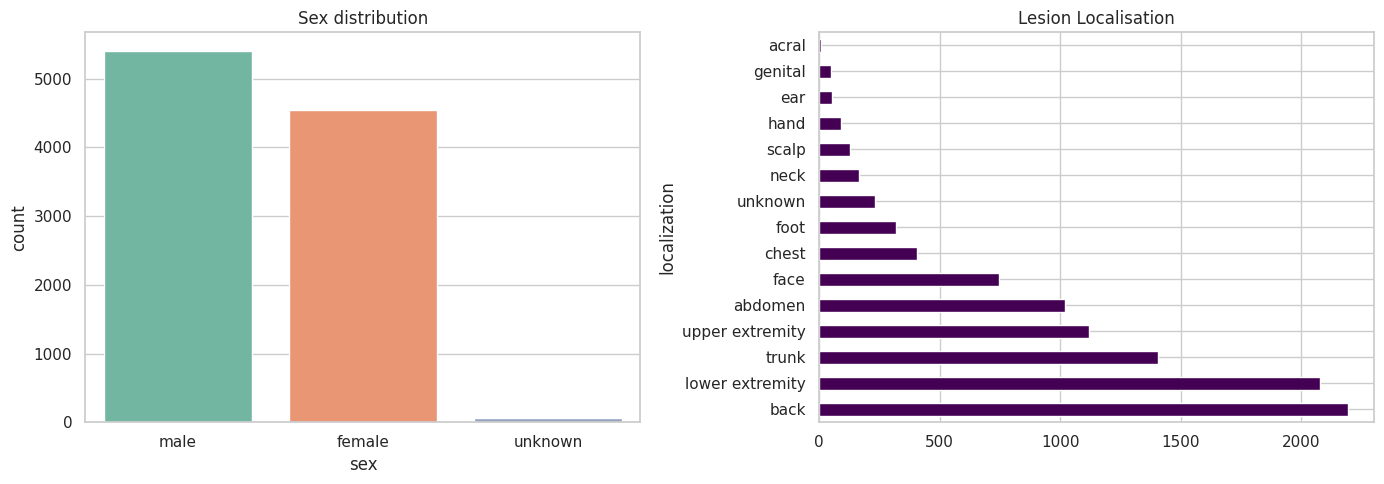

In [ ]:
# 3.2 Sex and localisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='sex', ax=axes[0], palette='Set2')
axes[0].set_title('Sex distribution')
df['localization'].value_counts().plot(kind='barh', ax=axes[1], colormap='viridis')
axes[1].set_title('Lesion Localisation')
plt.tight_layout(); plt.show()

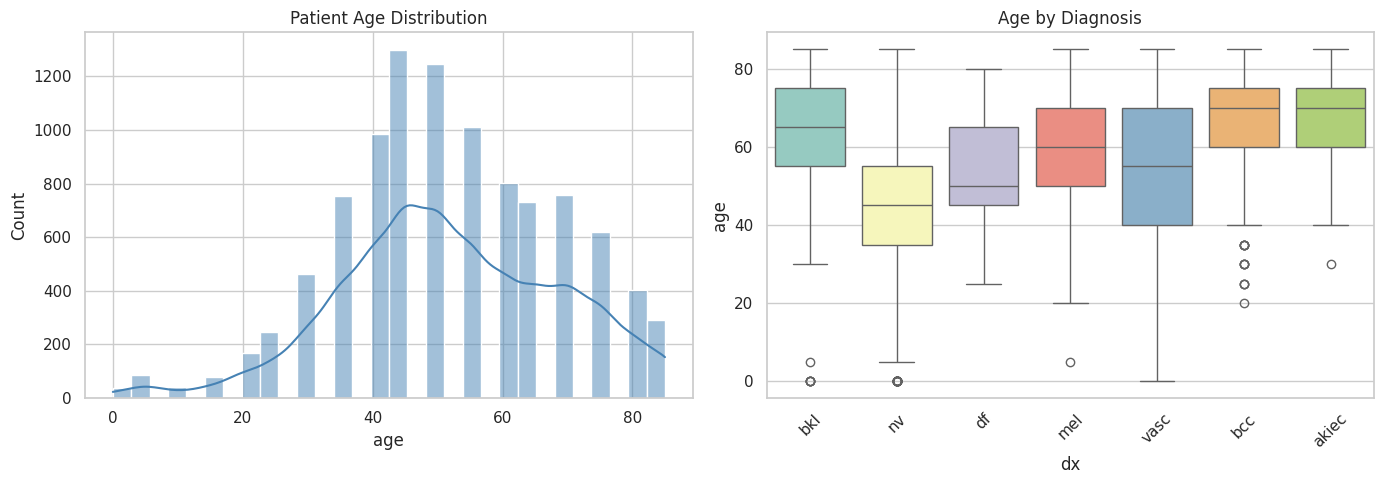

In [ ]:
# 3.3 Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Patient Age Distribution')
sns.boxplot(data=df, x='dx', y='age', ax=axes[1], palette='Set3')
axes[1].set_title('Age by Diagnosis'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 4. Multivariate Analysis

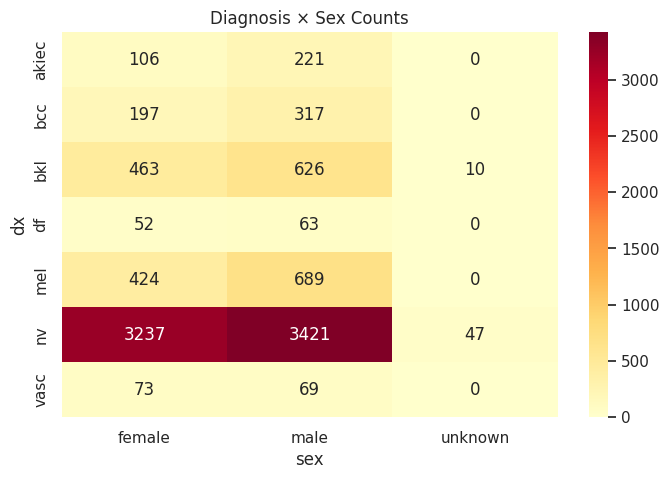

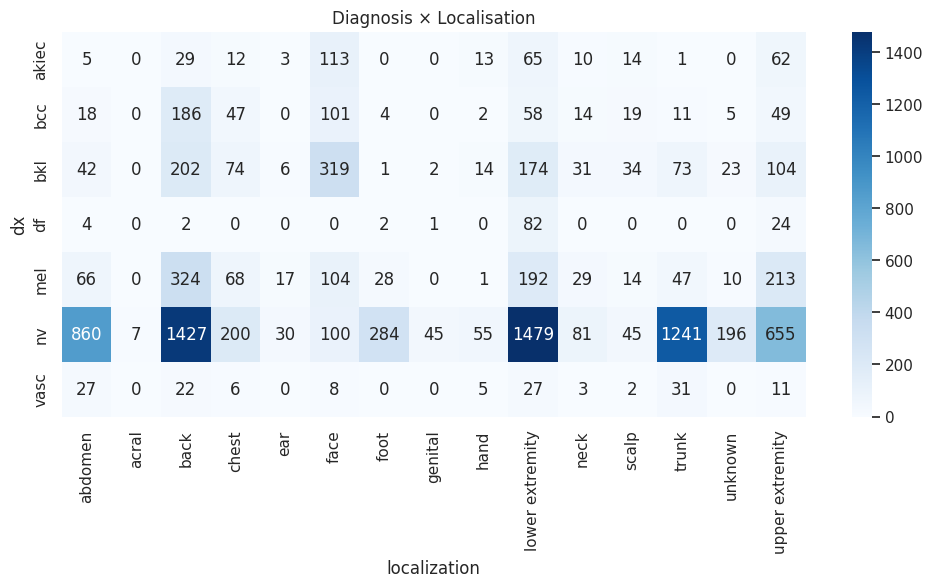

In [ ]:
# 4.1 dx vs sex heatmap
ct = pd.crosstab(df['dx'], df['sex'])
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Diagnosis × Sex Counts')
plt.show()

# 4.2 dx vs localization
ct2 = pd.crosstab(df['dx'], df['localization'])
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Diagnosis × Localisation')
plt.show()

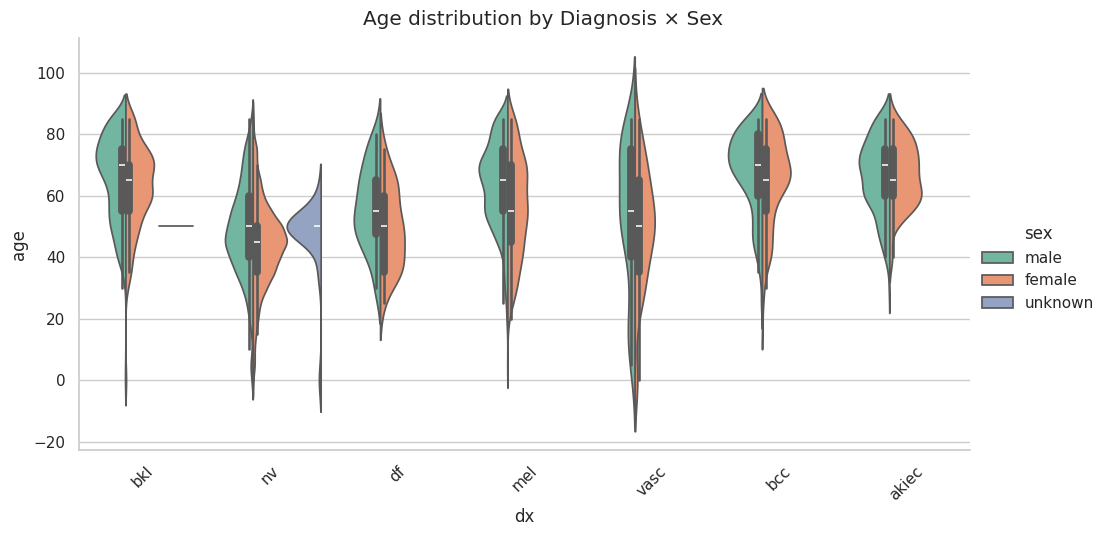

In [ ]:
# 4.3 Faceted view — age, sex, diagnosis
g = sns.catplot(data=df, x='dx', y='age', hue='sex', kind='violin', height=5,
                aspect=2, palette='Set2', split=True)
g.set_xticklabels(rotation=45)
g.fig.suptitle('Age distribution by Diagnosis × Sex', y=1.02)
plt.show()

In [ ]:
# 4.4 Interactive sunburst
fig = px.sunburst(df, path=['sex','dx','localization'], values=None, title='Sex → Diagnosis → Localisation')
fig.show()

## 5. Image-level EDA

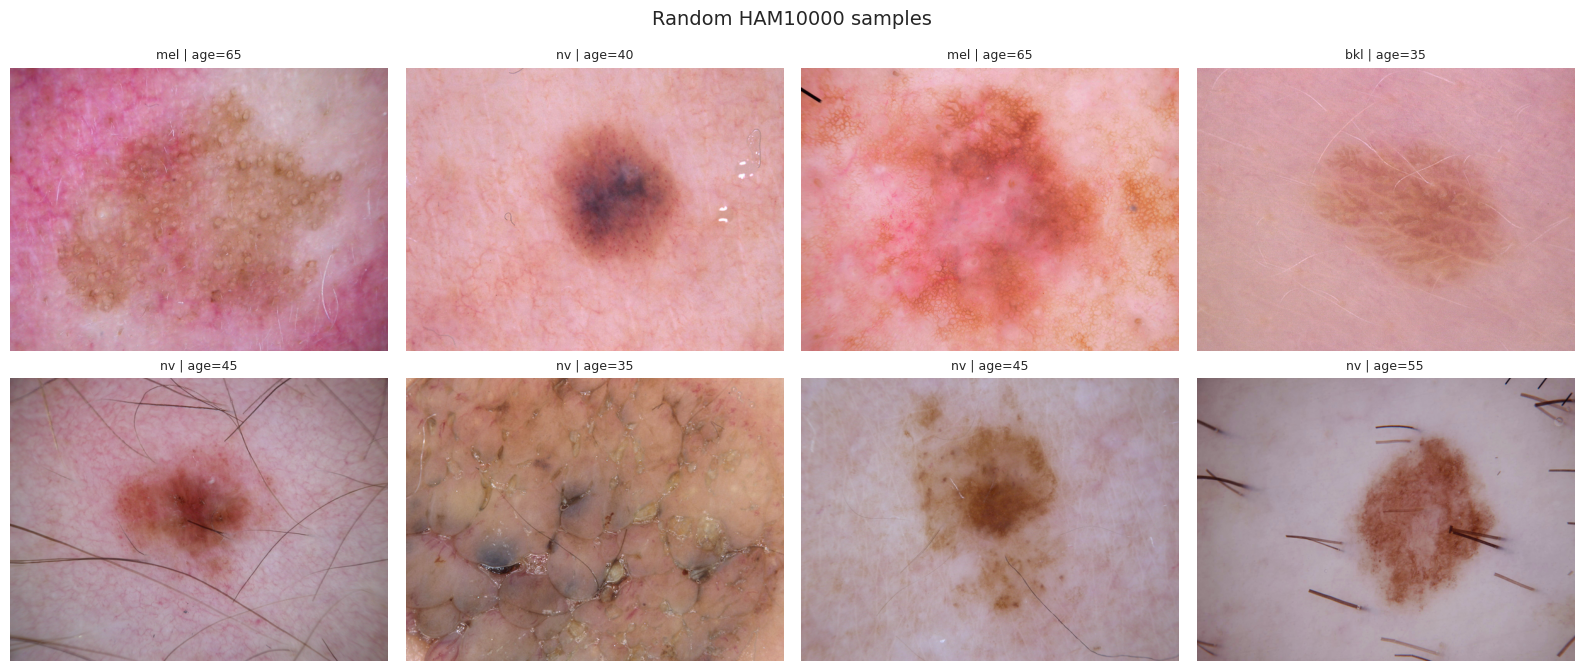

In [ ]:
def show_grid(subset, n=4, title=''):
    fig, axes = plt.subplots(2, n, figsize=(16, 7))
    chosen = subset.sample(2*n, random_state=SEED).reset_index(drop=True)
    for i, ax in enumerate(axes.flat):
        img = Image.open(chosen.loc[i, 'path'])
        ax.imshow(img); ax.axis('off')
        ax.set_title(f"{chosen.loc[i,'dx']} | age={chosen.loc[i,'age']:.0f}", fontsize=9)
    plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()

show_grid(df, n=4, title='Random HAM10000 samples')

In [ ]:
# Image colour-channel statistics (sampled)
sample = df.sample(min(400, len(df)), random_state=SEED)
rows = []
for _, r in sample.iterrows():
    arr = np.array(Image.open(r['path']).convert('RGB').resize((100,75)))
    rows.append({'dx':r['dx'],
                 'R_mean':arr[...,0].mean(), 'G_mean':arr[...,1].mean(), 'B_mean':arr[...,2].mean(),
                 'R_std':arr[...,0].std(),  'G_std':arr[...,1].std(),  'B_std':arr[...,2].std()})
img_stats = pd.DataFrame(rows)
img_stats.head()

,dx,R_mean,G_mean,B_mean,R_std,G_std,B_std
0,mel,193.120933,129.955200,142.478933,12.173246,21.580556,23.536116
1,nv,216.850400,157.852533,160.103600,21.586644,25.025840,25.906001
2,mel,224.821733,145.849333,141.188667,11.129388,25.799689,29.332439
3,bkl,206.426933,152.240800,154.277733,7.663672,12.710369,18.315023
4,nv,170.370533,134.457867,143.190667,16.984924,21.347086,26.118089


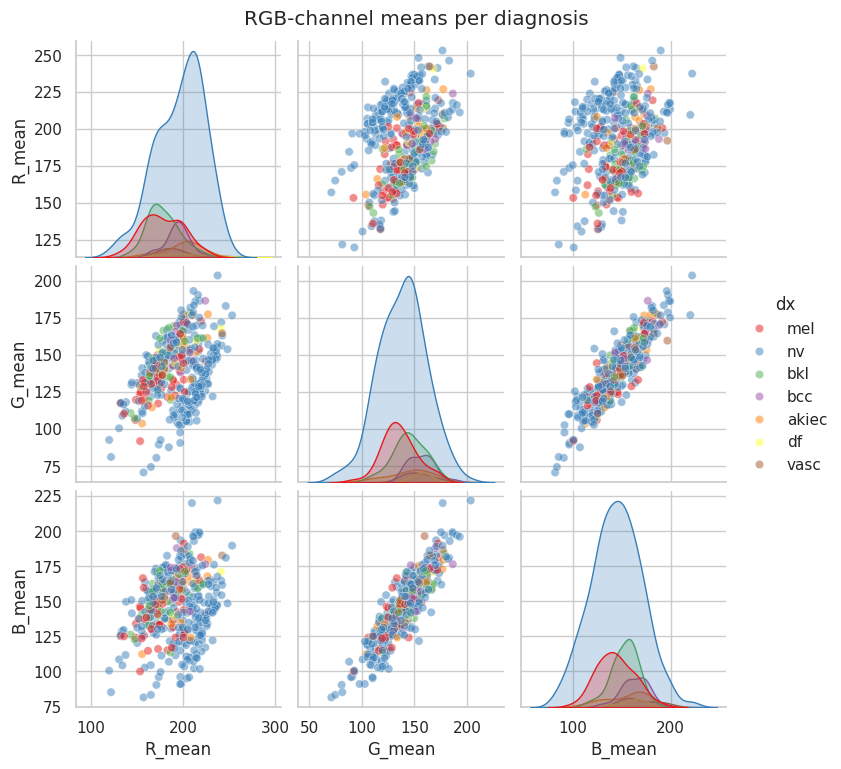

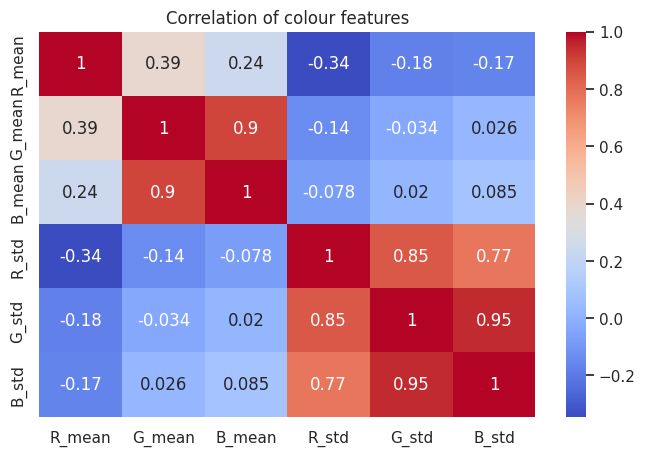

In [ ]:
sns.pairplot(img_stats[['R_mean','G_mean','B_mean','dx']], hue='dx',
             diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('RGB-channel means per diagnosis', y=1.02)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(img_stats.select_dtypes('number').corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation of colour features')
plt.show()

## 6. Binary Label Mapping

* **Malignant**: `mel` (melanoma), `bcc` (basal-cell carcinoma), `akiec` (actinic keratoses)
* **Benign**: `nv`, `bkl`, `df`, `vasc`

label
benign       8061
malignant    1954
Name: count, dtype: int64


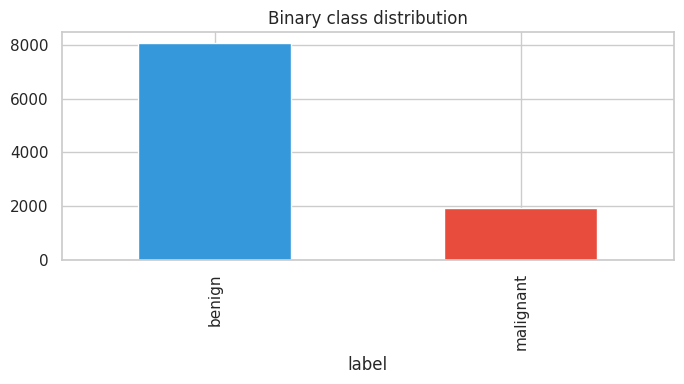

In [ ]:
MALIGNANT = {'mel','bcc','akiec'}
df['label'] = df['dx'].apply(lambda x: 'malignant' if x in MALIGNANT else 'benign')
print(df['label'].value_counts())

fig, ax = plt.subplots(figsize=(7,4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['#3498db','#e74c3c'])
ax.set_title('Binary class distribution'); plt.tight_layout(); plt.show()

## 7. Balanced Subset (~1500 images)

In [ ]:
PER_CLASS = 750
subset = pd.concat([
    df[df['label']=='benign'].sample(PER_CLASS, random_state=SEED),
    df[df['label']=='malignant'].sample(min(PER_CLASS, (df['label']=='malignant').sum()), random_state=SEED)
]).reset_index(drop=True)
print(subset['label'].value_counts())

train_df, test_df = train_test_split(subset, test_size=0.2, stratify=subset['label'], random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=SEED)
print('Train:', len(train_df), '| Val:', len(val_df), '| Test:', len(test_df))

label
benign       750
malignant    750
Name: count, dtype: int64
Train: 1020 | Val: 180 | Test: 300


## 8. Data Generators with Augmentation

Found 1020 validated image filenames belonging to 2 classes.
Found 180 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.


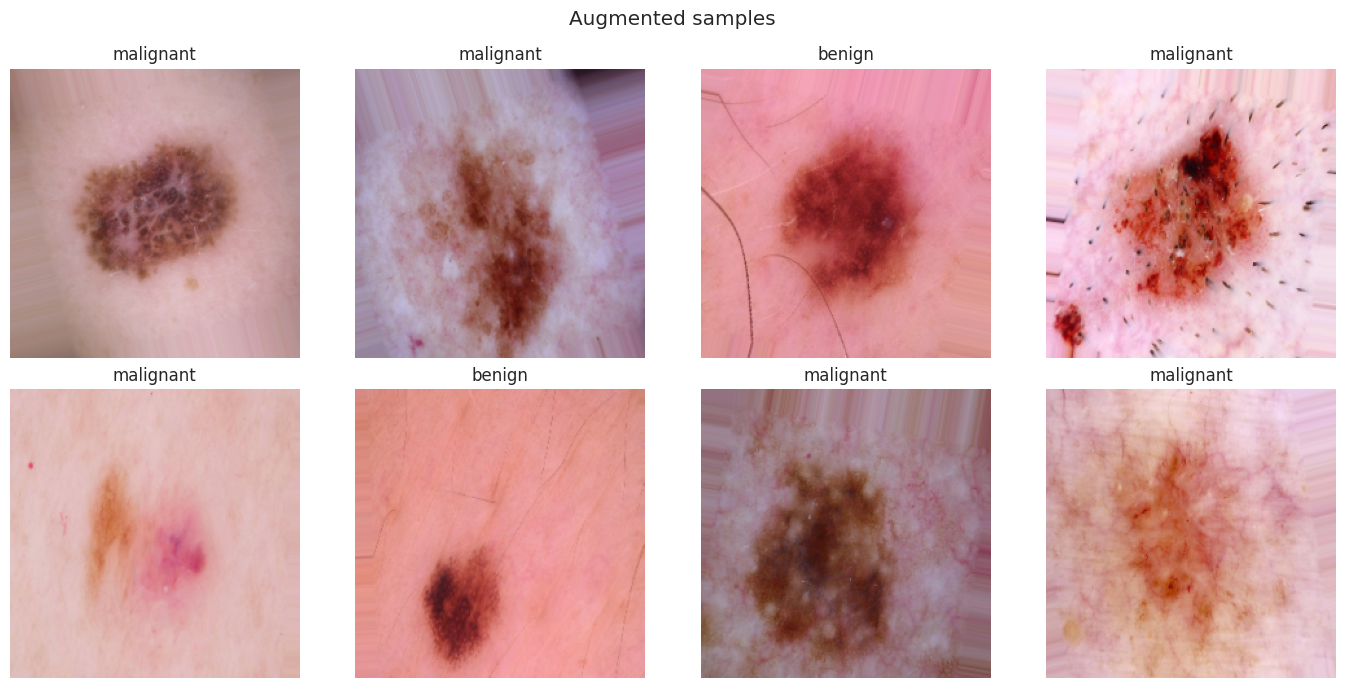

In [ ]:
IMG_SIZE = 224
BATCH = 32

train_aug = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.15,
                                width_shift_range=0.1, height_shift_range=0.1,
                                horizontal_flip=True, vertical_flip=True, fill_mode='nearest')
eval_aug  = ImageDataGenerator(rescale=1./255)

def make_flow(df_part, aug, shuffle):
    return aug.flow_from_dataframe(df_part, x_col='path', y_col='label',
                                    target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH,
                                    class_mode='binary', shuffle=shuffle, seed=SEED,
                                    classes=['benign','malignant'])

train_flow = make_flow(train_df, train_aug, True)
val_flow   = make_flow(val_df,   eval_aug,  False)
test_flow  = make_flow(test_df,  eval_aug,  False)

# Visualise augmented batch
x,y = next(train_flow)
fig, axes = plt.subplots(2, 4, figsize=(14,7))
for i, ax in enumerate(axes.flat):
    ax.imshow(x[i]); ax.axis('off')
    ax.set_title('benign' if y[i]==0 else 'malignant')
plt.suptitle('Augmented samples'); plt.tight_layout(); plt.show()

## 9. EfficientNetB0

In [ ]:
def build_effnet():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

effnet = build_effnet()
es = callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy')
hist_eff = effnet.fit(train_flow, validation_data=val_flow, epochs=8, callbacks=[es], verbose=1)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.5157 - loss: 0.7017 - val_accuracy: 0.5000 - val_loss: 0.6950
Epoch 2/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 587ms/step - accuracy: 0.5039 - loss: 0.7022 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 620ms/step - accuracy: 0.5020 - loss: 0.6998 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 4/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 585ms/step - accuracy: 0.4961 - loss: 0.7011 - val_accuracy: 0.5000 - val_loss: 0.6932


## 10. ResNet50

In [ ]:
def build_resnet():
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    m = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ])
    m.compile(optimizer=optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

resnet = build_resnet()
hist_res = resnet.fit(train_flow, validation_data=val_flow, epochs=8,
                       callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True,
                                                           monitor='val_accuracy')], verbose=1)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5176 - loss: 0.7584 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 2/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 599ms/step - accuracy: 0.4794 - loss: 0.7709 - val_accuracy: 0.5167 - val_loss: 0.6906
Epoch 3/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 632ms/step - accuracy: 0.5000 - loss: 0.7356 - val_accuracy: 0.5056 - val_loss: 0.6917
Epoch 4/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 591ms/step - accuracy: 0.5039 - loss: 0.7406 - val_accuracy: 0.5056 - val_loss: 0.6905
Epoch 5/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 632ms/step - accuracy: 0.5108 - loss: 0.7319 - val_accuracy: 0.5167 - val_loss: 0.6900


## 11. Comparative Evaluation

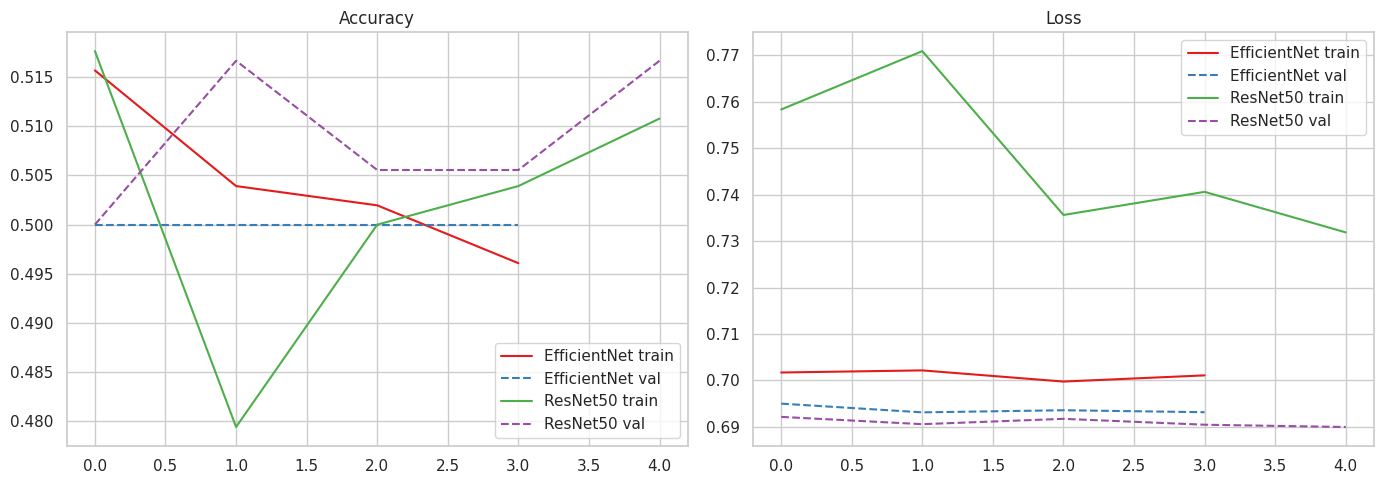

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for h, n in [(hist_eff,'EfficientNet'), (hist_res,'ResNet50')]:
    axes[0].plot(h.history['accuracy'], label=f'{n} train')
    axes[0].plot(h.history['val_accuracy'], '--', label=f'{n} val')
    axes[1].plot(h.history['loss'], label=f'{n} train')
    axes[1].plot(h.history['val_loss'], '--', label=f'{n} val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
def eval_model(m, name):
    test_flow.reset()
    probs = m.predict(test_flow, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)
    y = test_flow.classes
    fpr, tpr, _ = roc_curve(y, probs)
    return {'name':name,'preds':preds,'probs':probs,'y':y,
            'acc':accuracy_score(y,preds),'auc':auc(fpr,tpr),'fpr':fpr,'tpr':tpr}

results = [eval_model(effnet,'EfficientNetB0'), eval_model(resnet,'ResNet50')]
summary = pd.DataFrame([{'Model':r['name'],'Accuracy':r['acc'],'AUC':r['auc']} for r in results])
print(summary)

            Model  Accuracy       AUC
0  EfficientNetB0  0.500000  0.349156
1        ResNet50  0.513333  0.656044


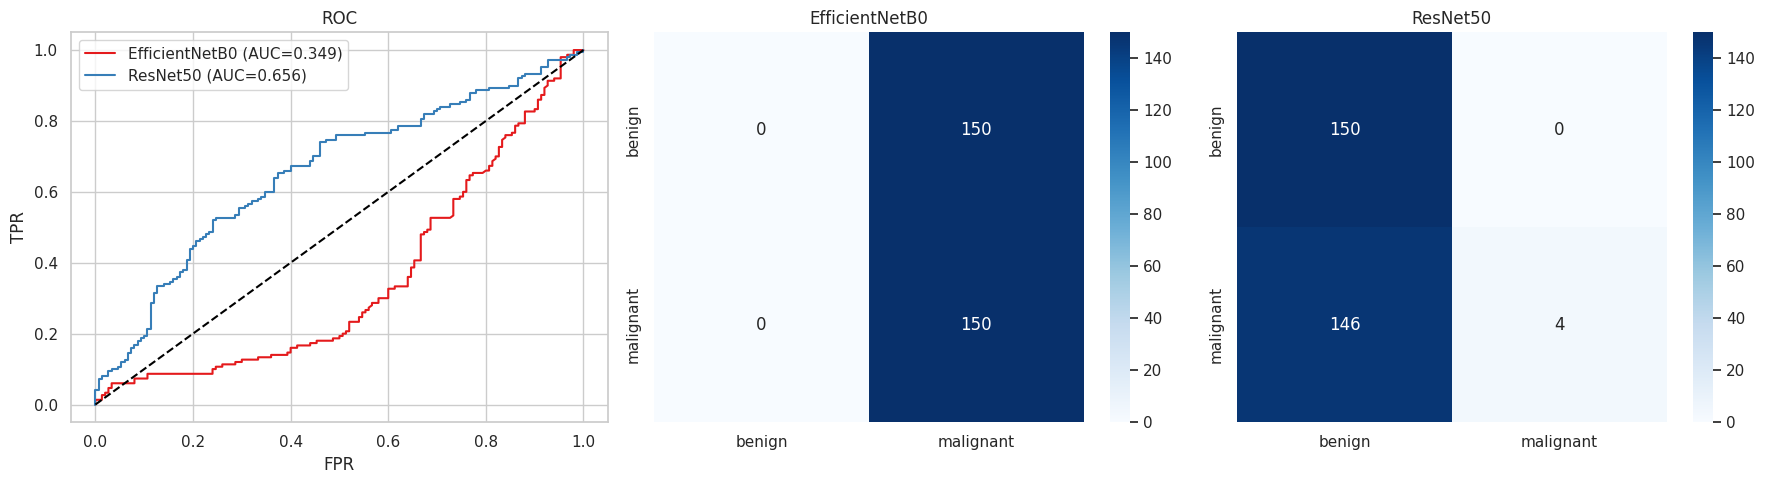


=== EfficientNetB0 ===
              precision    recall  f1-score   support

      benign       0.00      0.00      0.00       150
   malignant       0.50      1.00      0.67       150

    accuracy                           0.50       300
   macro avg       0.25      0.50      0.33       300
weighted avg       0.25      0.50      0.33       300


=== ResNet50 ===
              precision    recall  f1-score   support

      benign       0.51      1.00      0.67       150
   malignant       1.00      0.03      0.05       150

    accuracy                           0.51       300
   macro avg       0.75      0.51      0.36       300
weighted avg       0.75      0.51      0.36       300



In [ ]:
# ROC + confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for r in results:
    axes[0].plot(r['fpr'], r['tpr'], label=f"{r['name']} (AUC={r['auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

for ax, r in zip(axes[1:], results):
    cm = confusion_matrix(r['y'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['benign','malignant'], yticklabels=['benign','malignant'], ax=ax)
    ax.set_title(r['name'])
plt.tight_layout(); plt.show()

for r in results:
    print(f"\n=== {r['name']} ===")
    print(classification_report(r['y'], r['preds'], target_names=['benign','malignant']))